Unsupervised learning is a type of machine learning where the model is trained on data without labeled outputs. In other words, the algorithm tries to find hidden patterns, structures, or relationships in the data without any explicit guidance.

Input: Features (X)

Output: No predefined labels (Y)

The goal is to discover structure or groupings in the data.

Key Characteristics

* No labeled data (no target variable).

* Finds hidden patterns, clusters, or associations.

* Commonly used for exploration, dimensionality reduction, and anomaly detection

# Import Libraries

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pandas & numpy → handling data

matplotlib & seaborn → visualize clusters

load_iris → load Iris dataset

KMeans → clustering algorithm

StandardScaler → scale features for better clustering

PCA → reduce dimensionality to 2D for visualization

# Load the Iris Dataset

In [ ]:
# Load Iris data
iris = load_iris()
X = iris.data  # features only (unsupervised)
df = pd.DataFrame(X, columns=iris.feature_names)

# Display first 5 rows
print(df.head())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


We are using the Iris dataset which contains:

150 flower samples.

4 features for each flower:

* Sepal Length

* Sepal Width

* Petal Length

* Petal Width

3 flower species (which is not specified)

* We only take the features (sepal & petal measurements).

* In unsupervised learning, we do not use labels (species) because we want the model to discover patterns on its own.

We use unsupervised learning for this Iris model because we don’t provide the species labels to the algorithm. The goal is to let the model discover natural groupings or patterns in the flower measurements on its own. This helps us explore the data, find clusters, and understand inherent structure without prior knowledge.

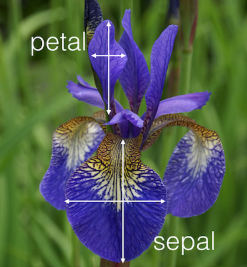

# Standardize Features

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

* Scaling ensures all features have mean = 0 and variance = 1.

* Important for K-Means because it uses distance (Euclidean distance) to form clusters.

# Determine Optimal Number of Clusters

In [ ]:
# Elbow Method
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

* inertia = []

An empty list is created to store the inertia values for each number of clusters. Inertia measures how spread out the data points are within each cluster (lower inertia means tighter clusters).

* for k in range(1, 11):

A loop runs through values of k from 1 to 10, meaning the code will test 10 different numbers of clusters.

* kmeans = KMeans(n_clusters=k, random_state=42)

For each value of k, a K-Means model is created with that number of clusters.
The random_state=42 ensures the results are reproducible (you get the same output each time you run the code).

* kmeans.fit(X_scaled)

The model is trained on the scaled dataset (X_scaled). K-Means groups the data into k clusters by minimizing the distance between data points and their cluster centers.

* inertia.append(kmeans.inertia_)

The inertia value (sum of squared distances between points and their nearest cluster center) is recorded for each k and added to the list.

In [ ]:
# Print the inertia values
for i, val in enumerate(inertia, start=1):
    print(f"Number of clusters = {i}, Inertia = {val:.2f}")

Number of clusters = 1, Inertia = 600.00
Number of clusters = 2, Inertia = 222.36
Number of clusters = 3, Inertia = 191.02
Number of clusters = 4, Inertia = 114.35
Number of clusters = 5, Inertia = 91.05
Number of clusters = 6, Inertia = 81.55
Number of clusters = 7, Inertia = 80.78
Number of clusters = 8, Inertia = 64.43
Number of clusters = 9, Inertia = 55.71
Number of clusters = 10, Inertia = 51.12


Inertia decreases as clusters increase.

The sharp drop happens until around k = 3, after which the improvement becomes smaller.
→ That’s why 3 clusters is considered optimal.

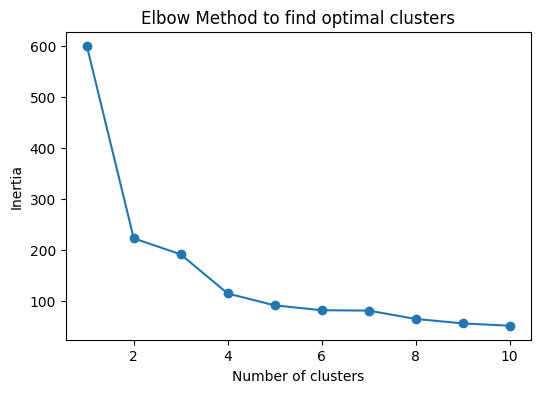

In [ ]:
# Plot
plt.figure(figsize=(6,4))
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method to find optimal clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

The sharp drop happens until k = 3.

After that, the curve flattens — meaning adding more clusters doesn’t reduce inertia much.

Therefore, the optimal number of clusters = 3.

# Apply K-Means Clustering

In [ ]:
# K-Means with 3 clusters (we know Iris has 3 species)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster info to dataframe
df['Cluster'] = clusters
print(df.head())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        1  
1        2  
2        2  
3        2  
4        1  


KMeans(n_clusters=3) → creates a model to form 3 clusters (for the 3 Iris species).

fit_predict(X_scaled) → trains the model and assigns each sample to a cluster (0, 1, or 2).

df['Cluster'] = clusters → adds the cluster labels to the DataFrame.

print(df.head()) → displays the first few rows to verify cluster assignment.

* Each row is a flower with its features (sepal and petal measurements), and the last column “Cluster” shows the group (0, 1, or 2) assigned by the model.

* The model has grouped similar flowers together based on their measurements.

* Cluster numbers (0, 1, 2) are labels assigned by K-Means, not actual species names — they just indicate which group each flower belongs to.

# Visualize Clusters (using PCA for 2D)

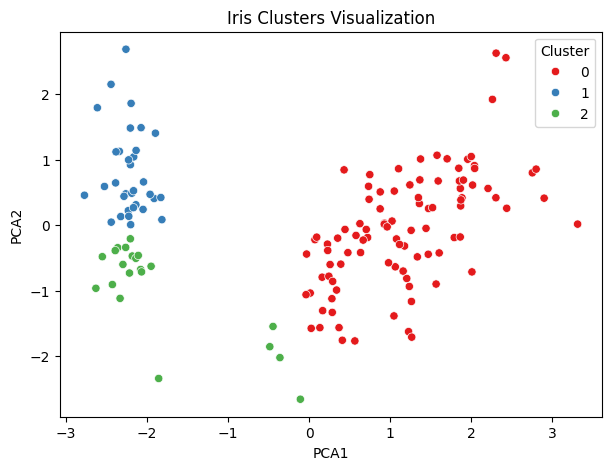

In [ ]:
# Reduce dimensions to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

# Plot clusters
plt.figure(figsize=(7,5))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set1')
plt.title("Iris Clusters Visualization")
plt.show()


PCA reduces 4D features to 2D → easy visualization

Scatter plot shows how K-Means separated flowers into clusters

df['PCA1'] and df['PCA2'] are the two new dimensions created by PCA
to represent and visualize the 4D Iris data on a 2D plot.

Cluster Colors

Red dots (Cluster 0) — one group of flowers

Blue dots (Cluster 1) — another group

Green dots (Cluster 2) — third group

The plot shows three distinct clusters, meaning the algorithm successfully grouped the flowers based on similarities in their features.

The red cluster (Cluster 0) is clearly separated from the others — indicating one unique species (likely Iris-setosa).

The blue and green clusters (Clusters 1 and 2) slightly overlap — showing these two species (versicolor and virginica) have more similar feature patterns.